In [1]:
import matplotlib.pyplot as plt
from scipy.signal import lfilter
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

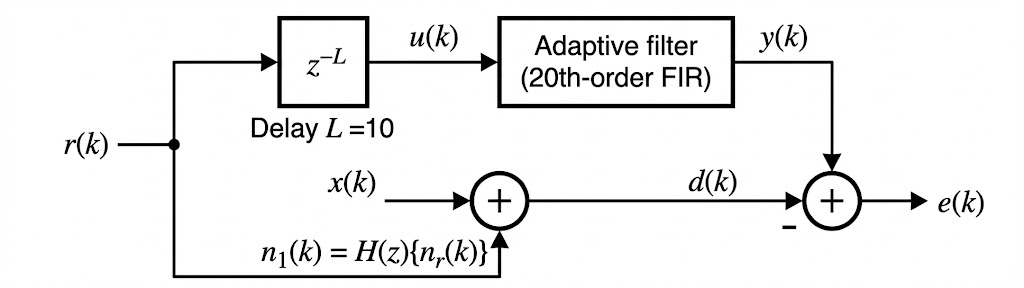
In a signal enhancement problem, the reference signal is $r(k)=\sin(0.2 \pi k) + n_r(k)$ 
* $n_r (k)$ is zero-mean Gaussian white noise with variance $σ^2_{n_r} = 10$ and pass through a filter with transfer function $H(z)=0.4/(z^2-1.36z+0.79)$
* The adaptive filter is a 20th-order FIR filter. In all examples, a delay $L = 10$ is applied to the reference signal.
1. Target Signal (Clean Signal)The clean signal we wish to recover is a discrete-time sine wave:$$x(k) = \sin(0.2\pi k)$$
2. Reference SignalThe reference signal $r(k)$ consists of the clean signal corrupted by additive white Gaussian noise (AWGN):$$r(k) = x(k) + n_r(k)$$Noise Characteristics: $n_r(k)$ is zero-mean Gaussian white noise with variance $\sigma^2_{n_r} = 10$.
3. Interference Path (Noise Filter)The noise in the primary channel is a filtered version of the reference noise. The transfer function of the interference path is:$$H(z) = \frac{0.4}{z^2 - 1.36z + 0.79}$$
4. Desired Signal (Primary Input)The desired signal $d(k)$ contains the target clean signal and a filtered noise component $n_1(k)$:$$d(k) = x(k) + n_1(k)$$where the interference $n_1(k)$ is generated by passing the reference noise through the interference path:$$n_1(k) = H(z) \{n_r(k)\}$$Note: The interference component $n_1(k)$ originates only from the noise $n_r(k)$, not from the entire reference signal $r(k)$.
5. Adaptive Filter SetupThe adaptive filter aims to minimize the error between its output and the desired signal.Filter Type: 20th-order FIR Filter.Input Signal $u(k)$: The reference signal is delayed by $L = 10$ samples before entering the filter:$$u(k) = r(k - L), \quad L = 10$$

In [2]:
def signalEnhancedData(N, L, sigma_nr2=10.0,):
    """
    Generate one realization for signal enhancement problem

    Returns:
        u : adaptive input (delayed reference)
        d : desired signal
        x_clean : ground truth clean signal (for evaluation)
    """

    # noise
    nr = np.sqrt(sigma_nr2) * np.random.randn(N)

    # clean signal
    x_clean = np.sin(0.2 * np.pi * np.arange(N))

    # reference
    r = x_clean + nr

    # delay (adaptive input)
    u = np.roll(r, L)
    u[:L] = 0

    # H(z)
    b = [0.4]
    a = [1, -1.36, 0.79]

    # filtered noise
    n1 = lfilter(b, a, nr)

    # desired signal
    d = x_clean + n1

    return u, d, x_clean

In [3]:
def runSigEnhanced(
    model,
    N=2000,
    L=10,
    sigma_nr2=10.0,
    n_runs=100,
    burnin=500,
):
    """
    Monte-Carlo signal enhancement experiment

    Returns:
        mse_avg : averaged learning curve
        misadj  : steady-state misadjustment (vs noise floor)
    """

    # determine output length
    u_test, d_test, x_test = signalEnhancedData(N, L, sigma_nr2)

    model.w = np.zeros_like(model.w)
    _, e_test, _ = model(u_test, d_test, train=False)
    out_len = len(e_test)

    mse_runs = np.zeros((n_runs, out_len))

    for r in range(n_runs):
        u, d, x_clean = signalEnhancedData(N, L, sigma_nr2)

        model.w = np.zeros_like(model.w)

        y, e, _ = model(u, d, train=True)

        mse_runs[r] = (e - x_clean[:out_len])**2

    mse_avg = np.mean(mse_runs, axis=0)

    burn = min(burnin, out_len // 2)

    # residual error
    misadj = np.mean(mse_avg[burn:])

    return mse_avg, misadj

/tmp/ipykernel_947/1091010297.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  mse_runs[r] = (e - x_clean[:out_len])**2


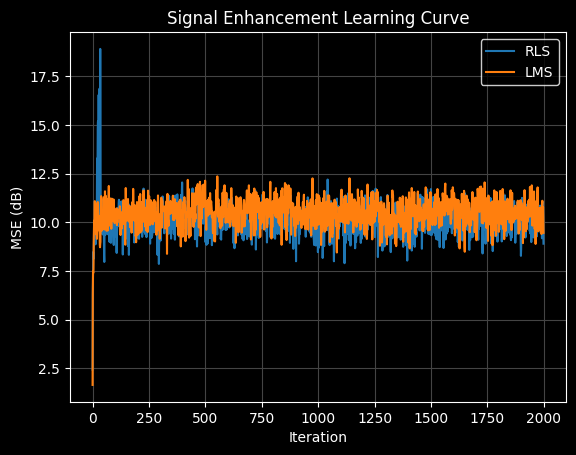

RLS residual: 10.345372663716345
LMS residual: 11.422148180580391


In [4]:
# RLS
M = 20
rls_model = adspfilter.RLS(mu=None, lam=0.99, delta=1e-2, filter_order=M-1)
mse_rls, M_rls = runSigEnhanced(rls_model)

# LMS
lms_model = adspfilter.LMS(mu=0.001, filter_order=M-1)
mse_lms, M_lms = runSigEnhanced(lms_model)

# plot
plt.figure()
plt.plot(10*np.log10(mse_rls), label="RLS")
plt.plot(10*np.log10(mse_lms), label="LMS")
plt.title("Signal Enhancement Learning Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.legend()
plt.grid()
plt.show()

print("RLS residual:", M_rls)
print("LMS residual:", M_lms)

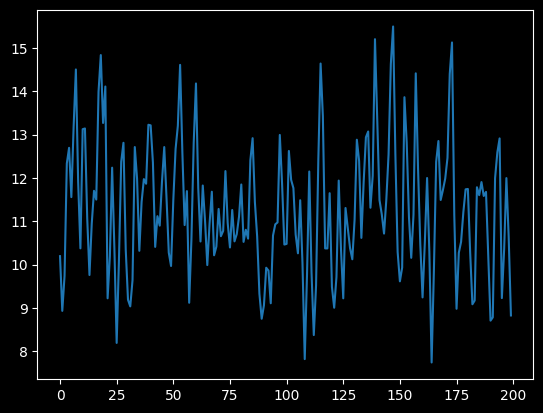

In [9]:
plt.plot(mse_lms[-200:])

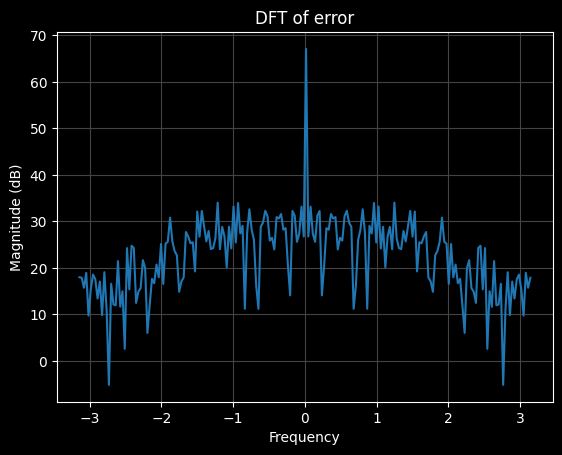

In [10]:
E = np.fft.fft(mse_lms[-200:])
E_db = 20*np.log10(np.abs(E) + 1e-12)

plt.plot(np.linspace(-np.pi, np.pi, len(E_db)), np.fft.fftshift(E_db))
plt.title("DFT of error")
plt.xlabel("Frequency")
plt.ylabel("Magnitude (dB)")
plt.grid()

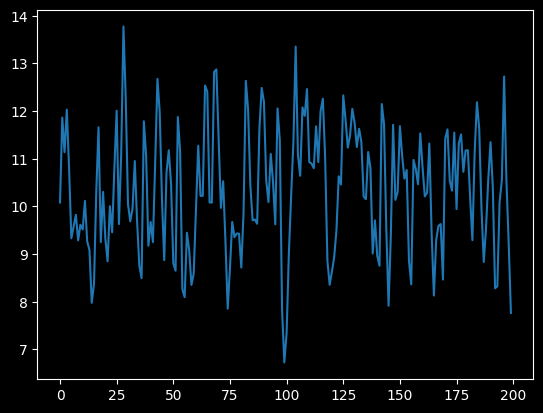

In [11]:
plt.plot(mse_rls[-200:])

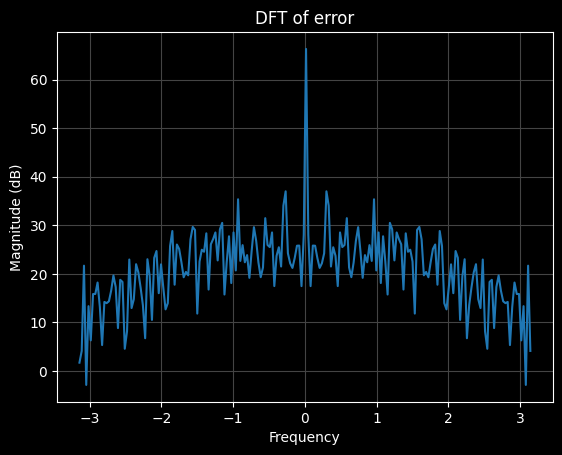

In [12]:
E = np.fft.fft(mse_rls[-200:])
E_db = 20*np.log10(np.abs(E) + 1e-12)

plt.plot(np.linspace(-np.pi, np.pi, len(E_db)), np.fft.fftshift(E_db))
plt.title("DFT of error")
plt.xlabel("Frequency")
plt.ylabel("Magnitude (dB)")
plt.grid()